# Import Packages

In [2]:
# importing packages
import numpy as np # to perform calculations 
import pandas as pd # to read data
import matplotlib.pyplot as plt # to visualise

In [3]:
df = pd.read_csv("creditcard.csv")

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
# Check Balance of results of Data Set

df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
# Split the data into features and target variables
X = df.drop('Class', axis=1) # Feature Variables
y = df['Class'] # Target Variables

In [6]:
# Train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
# Make train test split
X_train, X_test, y_train, y_test = train_test_split(X,  y,  test_size=0.2, stratify=y, random_state=42)

In [8]:
# Scale the data

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Create Deep Learning model
import torch

In [10]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [11]:
# Create a neural network
import torch.nn as nn

In [13]:
class FraudModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

In [14]:
model = FraudModel(X_train_tensor.shape[1])

criterion = nn.BCEWithLogitsLoss() # Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
# Train Model

epochs = 100

for epoch in range(epochs):
    model.train()

    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/100, Loss: 0.7577
Epoch 2/100, Loss: 0.7439
Epoch 3/100, Loss: 0.7304
Epoch 4/100, Loss: 0.7172
Epoch 5/100, Loss: 0.7043
Epoch 6/100, Loss: 0.6915
Epoch 7/100, Loss: 0.6790
Epoch 8/100, Loss: 0.6667
Epoch 9/100, Loss: 0.6545
Epoch 10/100, Loss: 0.6423
Epoch 11/100, Loss: 0.6303
Epoch 12/100, Loss: 0.6183
Epoch 13/100, Loss: 0.6062
Epoch 14/100, Loss: 0.5942
Epoch 15/100, Loss: 0.5821
Epoch 16/100, Loss: 0.5700
Epoch 17/100, Loss: 0.5577
Epoch 18/100, Loss: 0.5454
Epoch 19/100, Loss: 0.5330
Epoch 20/100, Loss: 0.5205
Epoch 21/100, Loss: 0.5079
Epoch 22/100, Loss: 0.4951
Epoch 23/100, Loss: 0.4823
Epoch 24/100, Loss: 0.4694
Epoch 25/100, Loss: 0.4564
Epoch 26/100, Loss: 0.4434
Epoch 27/100, Loss: 0.4303
Epoch 28/100, Loss: 0.4172
Epoch 29/100, Loss: 0.4041
Epoch 30/100, Loss: 0.3910
Epoch 31/100, Loss: 0.3780
Epoch 32/100, Loss: 0.3650
Epoch 33/100, Loss: 0.3521
Epoch 34/100, Loss: 0.3393
Epoch 35/100, Loss: 0.3267
Epoch 36/100, Loss: 0.3142
Epoch 37/100, Loss: 0.3018
Epoch 38/1

In [16]:
#Evaluate the results

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.5).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[56864     0]
 [   98     0]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56864
         1.0       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.8189660184557784


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

### Analysis of initial run

As we can see, the model marked everything as not being fradulent. Before further investigation, my instincts hypothesize that the reason for this is because of how imbalanced the dataset is, the model figured the easiest way to minimize the loss is by simply marking everything as being non fradulent, since 56864/56962 (~99.8%) of the test data are non-fraudulent charges.

There are a few ways to approach this, I think the easiest applicable way is to add a larger penalty to the loss whenever the model is wrong about the model not being fraudulent (models real life circumstances and severity)


In [17]:
# Calculate the imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


"""
pos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." 
Since the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.
"""

'\npos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." \nSince the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.\n'

In [18]:
# Train Model

epochs = 100

for epoch in range(epochs):
    model.train()

    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/100, Loss: 2.9035
Epoch 2/100, Loss: 2.7780
Epoch 3/100, Loss: 2.6133
Epoch 4/100, Loss: 2.4367
Epoch 5/100, Loss: 2.2643
Epoch 6/100, Loss: 2.1047
Epoch 7/100, Loss: 1.9599
Epoch 8/100, Loss: 1.8307
Epoch 9/100, Loss: 1.7166
Epoch 10/100, Loss: 1.6159
Epoch 11/100, Loss: 1.5277
Epoch 12/100, Loss: 1.4515
Epoch 13/100, Loss: 1.3862
Epoch 14/100, Loss: 1.3300
Epoch 15/100, Loss: 1.2814
Epoch 16/100, Loss: 1.2390
Epoch 17/100, Loss: 1.2022
Epoch 18/100, Loss: 1.1702
Epoch 19/100, Loss: 1.1420
Epoch 20/100, Loss: 1.1169
Epoch 21/100, Loss: 1.0945
Epoch 22/100, Loss: 1.0744
Epoch 23/100, Loss: 1.0564
Epoch 24/100, Loss: 1.0401
Epoch 25/100, Loss: 1.0254
Epoch 26/100, Loss: 1.0120
Epoch 27/100, Loss: 0.9997
Epoch 28/100, Loss: 0.9884
Epoch 29/100, Loss: 0.9779
Epoch 30/100, Loss: 0.9680
Epoch 31/100, Loss: 0.9586
Epoch 32/100, Loss: 0.9497
Epoch 33/100, Loss: 0.9412
Epoch 34/100, Loss: 0.9328
Epoch 35/100, Loss: 0.9247
Epoch 36/100, Loss: 0.9166
Epoch 37/100, Loss: 0.9085
Epoch 38/1

In [19]:
#Evaluate the results again

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.5).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[55489  1375]
 [   10    88]]
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     56864
         1.0       0.06      0.90      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC AUC: 0.9772667402639164


# Evaluation Pt 2.

As we can see, after including the penalty we decreased the number of false positives significantly from 98 to 11 cases (or a ~89% decrease). However, with that we see that the number of false negatives (cases that were counted as fraud but were not) surged a lot from 0 to 803.

In order to adjust this further investigation of the results is required

First I will create a probability distribution plot to see if it may be beneficial to adjust the threshold of the model

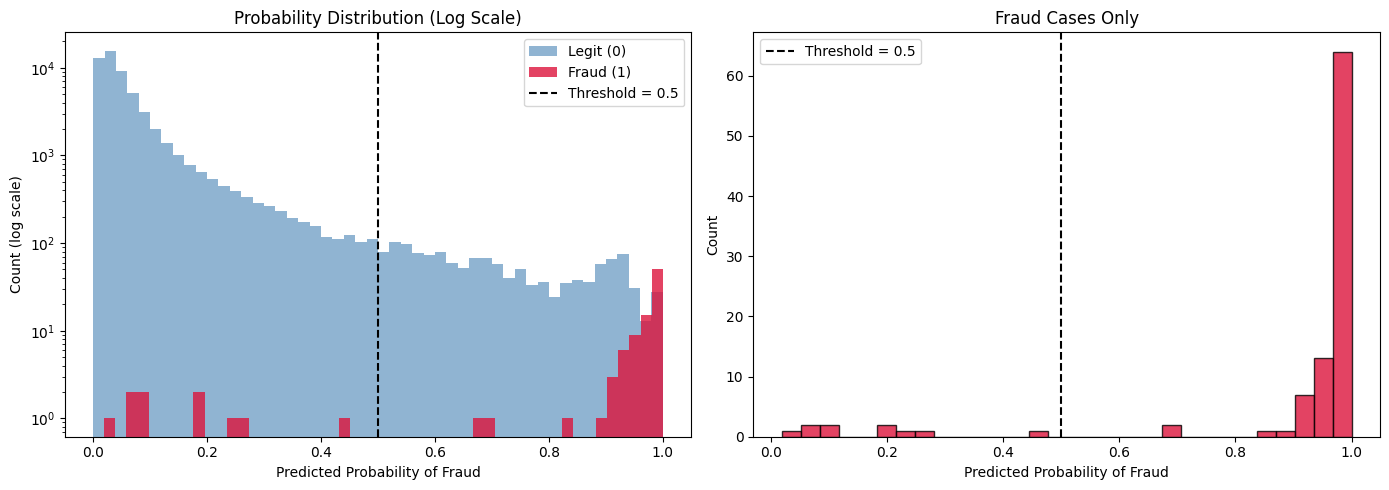

In [20]:
# Separate probabilities by true class
fraud_probs = probabilities.numpy()[y_test_tensor.numpy() == 1]
legit_probs = probabilities.numpy()[y_test_tensor.numpy() == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Probability Distribution
axes[0].hist(legit_probs, bins=50, alpha=0.6, color='steelblue', label='Legit (0)')
axes[0].hist(fraud_probs, bins=50, alpha=0.8, color='crimson', label='Fraud (1)')
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold = 0.5')
axes[0].set_yscale('log')  # log scale so fraud bars are visible
axes[0].set_xlabel('Predicted Probability of Fraud')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Probability Distribution (Log Scale)')
axes[0].legend()


# Plot 2: Recall vs Precision across thresholds 
from sklearn.metrics import precision_recall_curve

axes[1].hist(fraud_probs, bins=30, color='crimson', alpha=0.8, edgecolor='black')
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Threshold = 0.5')
axes[1].set_xlabel('Predicted Probability of Fraud')
axes[1].set_ylabel('Count')
axes[1].set_title('Fraud Cases Only')
axes[1].legend()

plt.tight_layout()
plt.show()

As we can see, a high majority of the fraud cases are above the 0.9 threshold, lets see the results of the model when we implement that threshold change

In [21]:
#Evaluate the results again

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.9).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[56652   212]
 [   14    84]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56864
         1.0       0.28      0.86      0.43        98

    accuracy                           1.00     56962
   macro avg       0.64      0.93      0.71     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9772667402639164


As we can see, the number of false negative cases did increase by a lot, but the number of false positive cases also increased

What we can now do to decrease the number of false positives is to oversample the fraud cases during training. This will allow the model to have more practice seeing fraud cases so that it can better recognize them

to do this we will be using SMOTE

In [22]:
from imblearn.over_sampling import SMOTE

# Create the resampled data
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train) 

# Then convert to tensors 
X_train_tensor = torch.tensor(X_resampled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_resampled.values, dtype=torch.float32)

In [23]:
# Rerun the model

model = FraudModel(X_train_tensor.shape[1])

# Calculate the imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


"""
pos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." 
Since the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.
"""

'\npos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." \nSince the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.\n'

In [24]:
# Train Model
class FraudModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

In [25]:
model = FraudModel(X_train_tensor.shape[1])  # reinitialize weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [26]:
epochs = 150

for epoch in range(epochs):
    model.train()

    logits = model(X_train_tensor).squeeze()
    loss = criterion(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/150, Loss: 266.5280
Epoch 2/150, Loss: 233.8652
Epoch 3/150, Loss: 204.0545
Epoch 4/150, Loss: 177.6291
Epoch 5/150, Loss: 154.8074
Epoch 6/150, Loss: 135.3824
Epoch 7/150, Loss: 119.0923
Epoch 8/150, Loss: 105.5714
Epoch 9/150, Loss: 94.3365
Epoch 10/150, Loss: 84.9231
Epoch 11/150, Loss: 76.9592
Epoch 12/150, Loss: 70.1665
Epoch 13/150, Loss: 64.3022
Epoch 14/150, Loss: 59.1751
Epoch 15/150, Loss: 54.6478
Epoch 16/150, Loss: 50.6148
Epoch 17/150, Loss: 46.9991
Epoch 18/150, Loss: 43.7488
Epoch 19/150, Loss: 40.8155
Epoch 20/150, Loss: 38.1576
Epoch 21/150, Loss: 35.7463
Epoch 22/150, Loss: 33.5539
Epoch 23/150, Loss: 31.5553
Epoch 24/150, Loss: 29.7294
Epoch 25/150, Loss: 28.0598
Epoch 26/150, Loss: 26.5315
Epoch 27/150, Loss: 25.1294
Epoch 28/150, Loss: 23.8399
Epoch 29/150, Loss: 22.6521
Epoch 30/150, Loss: 21.5560
Epoch 31/150, Loss: 20.5419
Epoch 32/150, Loss: 19.6015
Epoch 33/150, Loss: 18.7271
Epoch 34/150, Loss: 17.9119
Epoch 35/150, Loss: 17.1499
Epoch 36/150, Loss: 1

In [27]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.9).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[24718 32146]
 [    1    97]]
              precision    recall  f1-score   support

         0.0       1.00      0.43      0.61     56864
         1.0       0.00      0.99      0.01        98

    accuracy                           0.44     56962
   macro avg       0.50      0.71      0.31     56962
weighted avg       1.00      0.44      0.60     56962

ROC AUC: 0.972012259110172


The result ended in an overcorrection where the model got so good at recognizing fraud that it forgot what real looked like. In order to fix this I will soften the SMOTE. so that it is not 50/50

To aid this i will iteratively test different SMOTE ratios to see which one is optimal for training the model

In [30]:

from sklearn.metrics import precision_score, recall_score, f1_score


# Fix test tensor shape once before the loop
y_test_tensor_fixed = y_test_tensor.squeeze()   # (56962,1) to (56962,)
X_test_tensor_fixed = X_test_tensor.clone()

sampling_strategies = [0.05, 0.1, 0.2, 0.25, 0.3, 0.35, 0.5]
results = []

for strategy in sampling_strategies:

    # Resample
    sm = SMOTE(random_state=42, sampling_strategy=strategy)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    X_res_tensor = torch.tensor(X_res, dtype=torch.float32)
    y_res_tensor = torch.tensor(y_res.values, dtype=torch.float32)  # flat (n,)

    # Recalculate pos_weight from original y_train (not resampled)
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Retrain from scratch
    model = FraudModel(X_res_tensor.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(100):
        model.train()
        logits = model(X_res_tensor).squeeze()   # (n,1) to (n,)
        loss = criterion(logits, y_res_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate on held-out test set
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_tensor_fixed)
        probs = torch.sigmoid(test_logits).squeeze()
        preds = (probs >= 0.9).int()

    y_true = y_test_tensor_fixed.numpy()
    y_pred = preds.numpy()

    r = {
        'sampling_strategy': strategy,
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'false_negatives': int(((y_true == 1) & (y_pred == 0)).sum()),
        'false_positives': int(((y_true == 0) & (y_pred == 1)).sum())
    }
    results.append(r)
    print(f"strategy={strategy:.2f} | P={r['precision']} R={r['recall']} F1={r['f1']} | FN={r['false_negatives']} FP={r['false_positives']}")

print("\n", pd.DataFrame(results).to_string(index=False))

strategy=0.05 | P=0.0281 R=0.9082 F1=0.0546 | FN=9 FP=3076
strategy=0.10 | P=0.0099 R=0.9286 F1=0.0196 | FN=7 FP=9099
strategy=0.20 | P=0.0044 R=0.9796 F1=0.0087 | FN=2 FP=21788
strategy=0.25 | P=0.0064 R=0.9694 F1=0.0127 | FN=3 FP=14757
strategy=0.30 | P=0.0059 R=0.9796 F1=0.0118 | FN=2 FP=16100
strategy=0.35 | P=0.0056 R=0.9592 F1=0.0112 | FN=4 FP=16621
strategy=0.50 | P=0.005 R=0.9592 F1=0.01 | FN=4 FP=18662

  sampling_strategy  precision  recall     f1  false_negatives  false_positives
              0.05     0.0281  0.9082 0.0546                9             3076
              0.10     0.0099  0.9286 0.0196                7             9099
              0.20     0.0044  0.9796 0.0087                2            21788
              0.25     0.0064  0.9694 0.0127                3            14757
              0.30     0.0059  0.9796 0.0118                2            16100
              0.35     0.0056  0.9592 0.0112                4            16621
              0.50     0.0050 

After doing this analysis I decided I am going to be using SMOTE with sampling strategy of 5% because it gives the highest precision and F1 scores


------------------

# New Model With Adjusted SMOTE sampling strategy

In [31]:
# Create the resampled data
sm = SMOTE(random_state=42, sampling_strategy=0.05)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train) 

# Then convert to tensors 
X_train_tensor = torch.tensor(X_resampled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_resampled.values, dtype=torch.float32)

In [32]:
# Rerun the model

model = FraudModel(X_train_tensor.shape[1])

# Calculate the imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


"""
pos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." 
Since the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.
"""

'\npos_weight tells the loss: "a false negative on a fraud case should cost this many times more than a false positive." \nSince the dataset has roughly 99% normal and 1% fraud, pos_weight would be ~99, making the model pay heavily for missing fraud.\n'

In [33]:
# Train Model
class FraudModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

In [34]:
model = FraudModel(X_train_tensor.shape[1])  # reinitialize weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
epochs = 150

for epoch in range(epochs):
    model.train()

    logits = model(X_train_tensor).squeeze()
    loss = criterion(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/150, Loss: 17.3657
Epoch 2/150, Loss: 16.0419
Epoch 3/150, Loss: 14.8241
Epoch 4/150, Loss: 13.7136
Epoch 5/150, Loss: 12.7047
Epoch 6/150, Loss: 11.7916
Epoch 7/150, Loss: 10.9641
Epoch 8/150, Loss: 10.2110
Epoch 9/150, Loss: 9.5189
Epoch 10/150, Loss: 8.8802
Epoch 11/150, Loss: 8.2895
Epoch 12/150, Loss: 7.7417
Epoch 13/150, Loss: 7.2310
Epoch 14/150, Loss: 6.7567
Epoch 15/150, Loss: 6.3179
Epoch 16/150, Loss: 5.9133
Epoch 17/150, Loss: 5.5428
Epoch 18/150, Loss: 5.2054
Epoch 19/150, Loss: 4.8991
Epoch 20/150, Loss: 4.6218
Epoch 21/150, Loss: 4.3711
Epoch 22/150, Loss: 4.1448
Epoch 23/150, Loss: 3.9405
Epoch 24/150, Loss: 3.7562
Epoch 25/150, Loss: 3.5900
Epoch 26/150, Loss: 3.4403
Epoch 27/150, Loss: 3.3055
Epoch 28/150, Loss: 3.1840
Epoch 29/150, Loss: 3.0747
Epoch 30/150, Loss: 2.9761
Epoch 31/150, Loss: 2.8872
Epoch 32/150, Loss: 2.8069
Epoch 33/150, Loss: 2.7343
Epoch 34/150, Loss: 2.6684
Epoch 35/150, Loss: 2.6087
Epoch 36/150, Loss: 2.5544
Epoch 37/150, Loss: 2.5051
Ep

In [36]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.90).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[54111  2753]
 [    9    89]]
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.98     56864
         1.0       0.03      0.91      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.93      0.52     56962
weighted avg       1.00      0.95      0.97     56962

ROC AUC: 0.9710296963467435


Now time to do the same process and iteratively test different thresholds to see what the optimal threshold is.

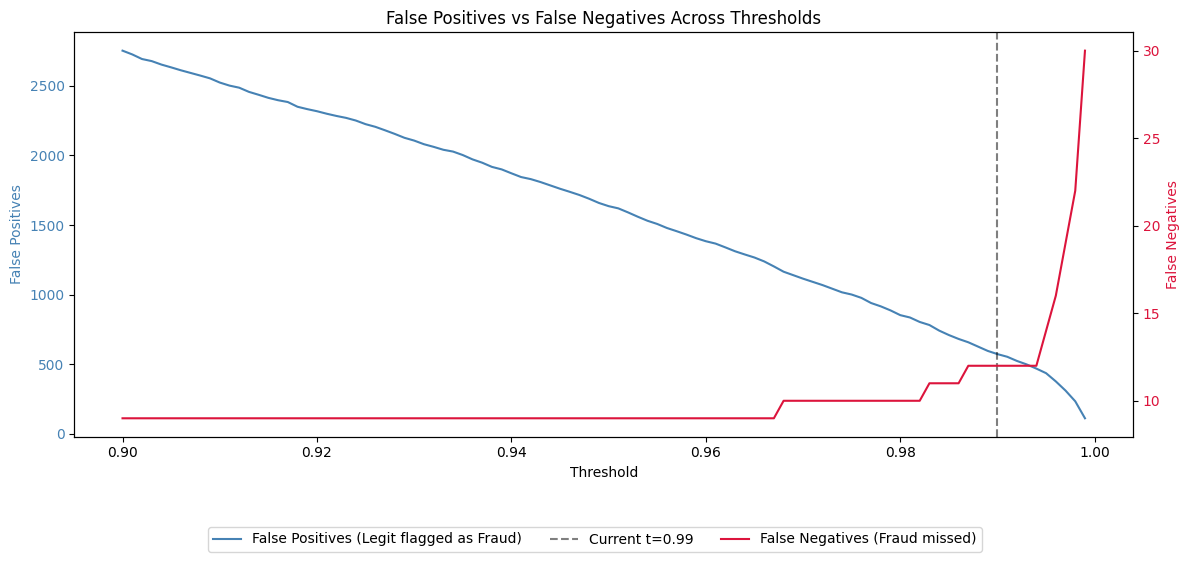

In [37]:
thresholds = np.arange(0.90, 1.0, 0.001)
fn_list, fp_list = [], []

for t in thresholds:
    preds = (probabilities.squeeze() >= t).int().numpy()
    y_true = y_test_tensor.squeeze().numpy()
    fn_list.append(int(((y_true == 1) & (preds == 0)).sum()))
    fp_list.append(int(((y_true == 0) & (preds == 1)).sum()))

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(thresholds, fp_list, color='steelblue', label='False Positives (Legit flagged as Fraud)')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('False Positives', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()  # second y-axis
ax2.plot(thresholds, fn_list, color='crimson', label='False Negatives (Fraud missed)')
ax2.set_ylabel('False Negatives', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Mark your current threshold
ax1.axvline(x=0.99, color='black', linestyle='--', alpha=0.5, label='Current t=0.99')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.title('False Positives vs False Negatives Across Thresholds')
plt.tight_layout()
plt.show()

![Threshold Analysis](ZoomIn_Of_Plot.png)

I am going to investigate region to see what the optimal spot is.

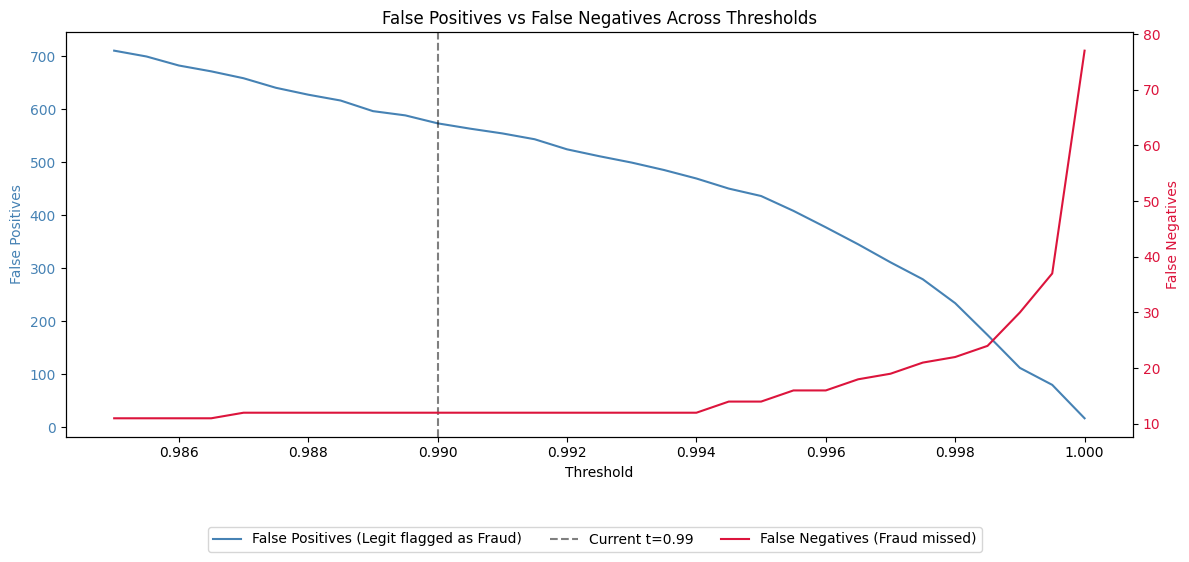

In [38]:
thresholds = np.arange(0.985, 1.0, 0.0005)  # zoom in to see region
fn_list, fp_list = [], []

for t in thresholds:
    preds = (probabilities.squeeze() >= t).int().numpy()
    y_true = y_test_tensor.squeeze().numpy()
    fn_list.append(int(((y_true == 1) & (preds == 0)).sum()))
    fp_list.append(int(((y_true == 0) & (preds == 1)).sum()))

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(thresholds, fp_list, color='steelblue', label='False Positives (Legit flagged as Fraud)')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('False Positives', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()  # second y-axis
ax2.plot(thresholds, fn_list, color='crimson', label='False Negatives (Fraud missed)')
ax2.set_ylabel('False Negatives', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Mark your current threshold
ax1.axvline(x=0.99, color='black', linestyle='--', alpha=0.5, label='Current t=0.99')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.title('False Positives vs False Negatives Across Thresholds')
plt.tight_layout()
plt.show()

The optimal threshold seems to be 0.996 (Or cases that are marked as 99.6% chance of fraud or higher)

Here are the results of that threshold

In [39]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.996).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[56487   377]
 [   16    82]]
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     56864
         1.0       0.18      0.84      0.29        98

    accuracy                           0.99     56962
   macro avg       0.59      0.92      0.65     56962
weighted avg       1.00      0.99      1.00     56962

ROC AUC: 0.9710296963467435


At this point I have done a lot of work finetuning this Deep Learning model, so because of that it is time to test whether it is overfitted. To do that I will perform a cross validation using the dataset

In [40]:
from sklearn.model_selection import StratifiedKFold

# I am using original unscaled data and scale each fold
X_cv = df.drop('Class', axis=1).values
y_cv = df['Class'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# StratifiedKFold preserves the fraud/legit ratio in each fold

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n--- Fold {fold+1}/5 ---")

    # Split
    X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
    y_tr, y_val = y_cv[train_idx], y_cv[val_idx]

    # Scale (fit on train only, transform both)
    scaler_cv = StandardScaler()
    X_tr = scaler_cv.fit_transform(X_tr)
    X_val = scaler_cv.transform(X_val)

    # SMOTE on train fold only
    sm = SMOTE(random_state=42, sampling_strategy=0.05)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)

    # Convert to tensors
    X_tr_tensor = torch.tensor(X_tr_res, dtype=torch.float32)
    y_tr_tensor = torch.tensor(y_tr_res, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

    # pos_weight from this fold's original train labels
    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    pw = torch.tensor([neg / pos], dtype=torch.float32)
    criterion_cv = nn.BCEWithLogitsLoss(pos_weight=pw)

    # Train
    model_cv = FraudModel(X_tr_tensor.shape[1])
    optimizer_cv = torch.optim.Adam(model_cv.parameters(), lr=0.001)

    for epoch in range(150):
        model_cv.train()
        logits = model_cv(X_tr_tensor).squeeze()
        loss = criterion_cv(logits, y_tr_tensor)
        optimizer_cv.zero_grad()
        loss.backward()
        optimizer_cv.step()

    # Evaluate
    model_cv.eval()
    with torch.no_grad():
        val_logits = model_cv(X_val_tensor)
        probs_cv = torch.sigmoid(val_logits).squeeze()
        preds_cv = (probs_cv >= 0.996).int().numpy()

    y_true_cv = y_val_tensor.numpy()

    result = {
        'fold': fold + 1,
        'precision': round(precision_score(y_true_cv, preds_cv, zero_division=0), 4),
        'recall':    round(recall_score(y_true_cv, preds_cv), 4),
        'f1':        round(f1_score(y_true_cv, preds_cv, zero_division=0), 4),
        'roc_auc':   round(roc_auc_score(y_true_cv, probs_cv.numpy()), 4),
        'fn':        int(((y_true_cv == 1) & (preds_cv == 0)).sum()),
        'fp':        int(((y_true_cv == 0) & (preds_cv == 1)).sum())
    }
    fold_results.append(result)
    print(f"P={result['precision']} R={result['recall']} F1={result['f1']} AUC={result['roc_auc']} | FN={result['fn']} FP={result['fp']}")

# Summary
results_df = pd.DataFrame(fold_results)
print("\n--- Cross Validation Summary ---")
print(results_df.to_string(index=False))
print(f"\nMean F1:      {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")
print(f"Mean Recall:  {results_df['recall'].mean():.4f} ± {results_df['recall'].std():.4f}")
print(f"Mean ROC AUC: {results_df['roc_auc'].mean():.4f} ± {results_df['roc_auc'].std():.4f}")


--- Fold 1/5 ---
P=0.1638 R=0.7778 F1=0.2707 AUC=0.9772 | FN=22 FP=393

--- Fold 2/5 ---
P=0.2092 R=0.8283 F1=0.334 AUC=0.9856 | FN=17 FP=310

--- Fold 3/5 ---
P=0.1942 R=0.8265 F1=0.3146 AUC=0.9798 | FN=17 FP=336

--- Fold 4/5 ---
P=0.1723 R=0.8367 F1=0.2857 AUC=0.9736 | FN=16 FP=394

--- Fold 5/5 ---
P=0.1907 R=0.7551 F1=0.3045 AUC=0.9716 | FN=24 FP=314

--- Cross Validation Summary ---
 fold  precision  recall     f1  roc_auc  fn  fp
    1     0.1638  0.7778 0.2707   0.9772  22 393
    2     0.2092  0.8283 0.3340   0.9856  17 310
    3     0.1942  0.8265 0.3146   0.9798  17 336
    4     0.1723  0.8367 0.2857   0.9736  16 394
    5     0.1907  0.7551 0.3045   0.9716  24 314

Mean F1:      0.3019 ± 0.0247
Mean Recall:  0.8049 ± 0.0362
Mean ROC AUC: 0.9776 ± 0.0055


While the model precision is not the best, it is appropriate to say that the model is not overfitted since it performed with a Mean ROC AUC score of 0.9776 with standard deviation of 0.0055, meaning that the model performed consistently across all folds.

This indicates that the model generalizes well to unseen data and is not overfitted to the training set. Mean recall on the fraud class holds steady at ~80% across all folds.

---------------

# Further fine-tuning the Deep Learning Model

Now at this point I have tried several different methods of adding larger penalties on the loss for incorrectly labeled true fraud cases, used SMOTE to allow the model to see more fraud cases to train off of, and finally changed the threshold of what is considered as guaranteed fraud so that the number of false positives are also limited. 

Now I will construct a new model and upgrade the model architecture to include Batch normalization and dropout so that the model makes more confident distinctions between fraud and legit.

In [56]:
class FraudModelV2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x)


In [57]:
model = FraudModelV2(X_train_tensor.shape[1])  # reinitialize weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [59]:
epochs = 150

for epoch in range(epochs):
    model.train()

    logits = model(X_train_tensor).squeeze()
    loss = criterion(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/150, Loss: 1.4702
Epoch 2/150, Loss: 1.4738
Epoch 3/150, Loss: 1.4650
Epoch 4/150, Loss: 1.4553
Epoch 5/150, Loss: 1.4547
Epoch 6/150, Loss: 1.4684
Epoch 7/150, Loss: 1.4401
Epoch 8/150, Loss: 1.4357
Epoch 9/150, Loss: 1.4344
Epoch 10/150, Loss: 1.4318
Epoch 11/150, Loss: 1.4363
Epoch 12/150, Loss: 1.4310
Epoch 13/150, Loss: 1.4217
Epoch 14/150, Loss: 1.4242
Epoch 15/150, Loss: 1.4204
Epoch 16/150, Loss: 1.4137
Epoch 17/150, Loss: 1.4145
Epoch 18/150, Loss: 1.4062
Epoch 19/150, Loss: 1.4034
Epoch 20/150, Loss: 1.3985
Epoch 21/150, Loss: 1.4005
Epoch 22/150, Loss: 1.3950
Epoch 23/150, Loss: 1.3941
Epoch 24/150, Loss: 1.3938
Epoch 25/150, Loss: 1.3756
Epoch 26/150, Loss: 1.3796
Epoch 27/150, Loss: 1.3861
Epoch 28/150, Loss: 1.3733
Epoch 29/150, Loss: 1.3740
Epoch 30/150, Loss: 1.3737
Epoch 31/150, Loss: 1.3598
Epoch 32/150, Loss: 1.3739
Epoch 33/150, Loss: 1.3604
Epoch 34/150, Loss: 1.3780
Epoch 35/150, Loss: 1.3506
Epoch 36/150, Loss: 1.3540
Epoch 37/150, Loss: 1.3461
Epoch 38/1

In [60]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities >= 0.996).int()

print(confusion_matrix(y_test_tensor.numpy(), predictions.numpy()))
print(classification_report(y_test_tensor.numpy(), predictions.numpy()))
print("ROC AUC:", roc_auc_score(y_test_tensor.numpy(), probabilities.numpy()))

[[56743   121]
 [   14    84]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56864
         1.0       0.41      0.86      0.55        98

    accuracy                           1.00     56962
   macro avg       0.70      0.93      0.78     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.9810813376419786


#### Analysis of cases and their probabilities

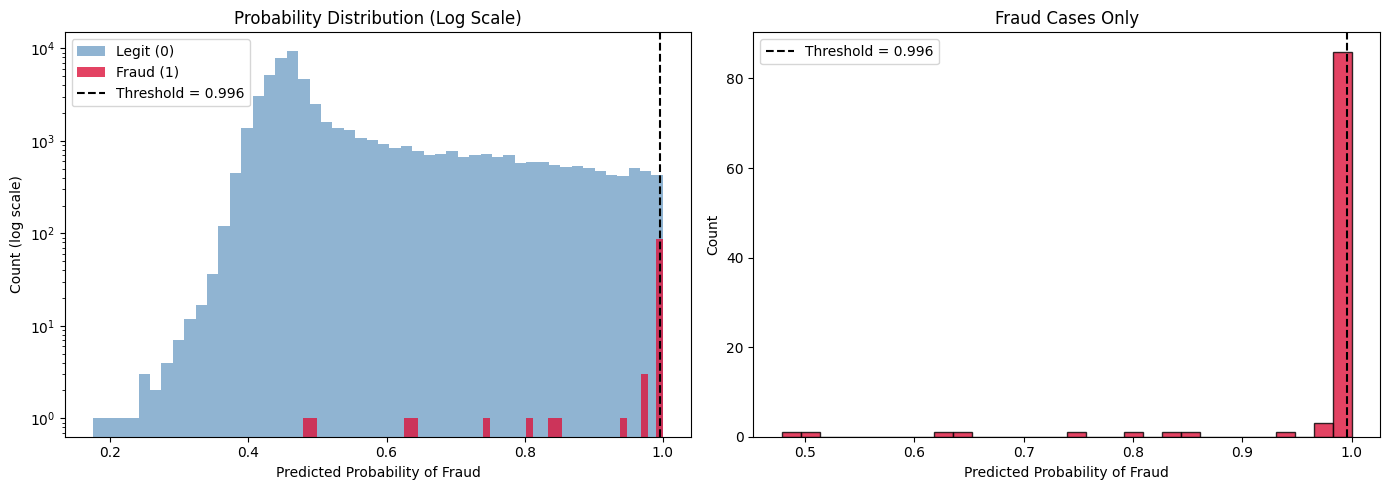

In [61]:
# Separate probabilities by true class
fraud_probs = probabilities.numpy()[y_test_tensor.numpy() == 1]
legit_probs = probabilities.numpy()[y_test_tensor.numpy() == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Probability Distribution
axes[0].hist(legit_probs, bins=50, alpha=0.6, color='steelblue', label='Legit (0)')
axes[0].hist(fraud_probs, bins=50, alpha=0.8, color='crimson', label='Fraud (1)')
axes[0].axvline(x=0.996, color='black', linestyle='--', label='Threshold = 0.996')
axes[0].set_yscale('log')  # log scale so fraud bars are visible
axes[0].set_xlabel('Predicted Probability of Fraud')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Probability Distribution (Log Scale)')
axes[0].legend()


# Plot 2: Recall vs Precision across thresholds 
from sklearn.metrics import precision_recall_curve

axes[1].hist(fraud_probs, bins=30, color='crimson', alpha=0.8, edgecolor='black')
axes[1].axvline(x=0.996, color='black', linestyle='--', label='Threshold = 0.996')
axes[1].set_xlabel('Predicted Probability of Fraud')
axes[1].set_ylabel('Count')
axes[1].set_title('Fraud Cases Only')
axes[1].legend()

plt.tight_layout()
plt.show()

The results are more accurate as seen by the ROC AUC score of 0.981.

The number of false negatives improved significantly and the number of false positive performed near the same.


## Testing for Overfitting

In [62]:
from sklearn.model_selection import StratifiedKFold

# I am using original unscaled data and scale each fold
X_cv = df.drop('Class', axis=1).values
y_cv = df['Class'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# StratifiedKFold preserves the fraud/legit ratio in each fold

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
    print(f"\n--- Fold {fold+1}/5 ---")

    # Split
    X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
    y_tr, y_val = y_cv[train_idx], y_cv[val_idx]

    # Scale (fit on train only, transform both)
    scaler_cv = StandardScaler()
    X_tr = scaler_cv.fit_transform(X_tr)
    X_val = scaler_cv.transform(X_val)

    # SMOTE on train fold only
    sm = SMOTE(random_state=42, sampling_strategy=0.05)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)

    # Convert to tensors
    X_tr_tensor = torch.tensor(X_tr_res, dtype=torch.float32)
    y_tr_tensor = torch.tensor(y_tr_res, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

    # pos_weight from this fold's original train labels
    neg = (y_tr == 0).sum()
    pos = (y_tr == 1).sum()
    pw = torch.tensor([neg / pos], dtype=torch.float32)
    criterion_cv = nn.BCEWithLogitsLoss(pos_weight=pw)

    # Train
    model_cv = FraudModelV2(X_tr_tensor.shape[1])
    optimizer_cv = torch.optim.Adam(model_cv.parameters(), lr=0.001)

    for epoch in range(150):
        model_cv.train()
        logits = model_cv(X_tr_tensor).squeeze()
        loss = criterion_cv(logits, y_tr_tensor)
        optimizer_cv.zero_grad()
        loss.backward()
        optimizer_cv.step()

    # Evaluate
    model_cv.eval()
    with torch.no_grad():
        val_logits = model_cv(X_val_tensor)
        probs_cv = torch.sigmoid(val_logits).squeeze()
        preds_cv = (probs_cv >= 0.996).int().numpy()

    y_true_cv = y_val_tensor.numpy()

    result = {
        'fold': fold + 1,
        'precision': round(precision_score(y_true_cv, preds_cv, zero_division=0), 4),
        'recall':    round(recall_score(y_true_cv, preds_cv), 4),
        'f1':        round(f1_score(y_true_cv, preds_cv, zero_division=0), 4),
        'roc_auc':   round(roc_auc_score(y_true_cv, probs_cv.numpy()), 4),
        'fn':        int(((y_true_cv == 1) & (preds_cv == 0)).sum()),
        'fp':        int(((y_true_cv == 0) & (preds_cv == 1)).sum())
    }
    fold_results.append(result)
    print(f"P={result['precision']} R={result['recall']} F1={result['f1']} AUC={result['roc_auc']} | FN={result['fn']} FP={result['fp']}")

# Summary
results_df = pd.DataFrame(fold_results)
print("\n--- Cross Validation Summary ---")
print(results_df.to_string(index=False))
print(f"\nMean F1:      {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")
print(f"Mean Recall:  {results_df['recall'].mean():.4f} ± {results_df['recall'].std():.4f}")
print(f"Mean ROC AUC: {results_df['roc_auc'].mean():.4f} ± {results_df['roc_auc'].std():.4f}")


--- Fold 1/5 ---
P=0.2542 R=0.7576 F1=0.3807 AUC=0.9771 | FN=24 FP=220

--- Fold 2/5 ---
P=0.2558 R=0.8889 F1=0.3973 AUC=0.9828 | FN=11 FP=256

--- Fold 3/5 ---
P=0.228 R=0.8469 F1=0.3593 AUC=0.9837 | FN=15 FP=281

--- Fold 4/5 ---
P=0.3451 R=0.7959 F1=0.4815 AUC=0.9759 | FN=20 FP=148

--- Fold 5/5 ---
P=0.3026 R=0.7041 F1=0.4233 AUC=0.9809 | FN=29 FP=159

--- Cross Validation Summary ---
 fold  precision  recall     f1  roc_auc  fn  fp
    1     0.2542  0.7576 0.3807   0.9771  24 220
    2     0.2558  0.8889 0.3973   0.9828  11 256
    3     0.2280  0.8469 0.3593   0.9837  15 281
    4     0.3451  0.7959 0.4815   0.9759  20 148
    5     0.3026  0.7041 0.4233   0.9809  29 159

Mean F1:      0.4084 ± 0.0471
Mean Recall:  0.7987 ± 0.0726
Mean ROC AUC: 0.9801 ± 0.0034


The ROC AUC variance of 0.0034 shows that the model is generalizing well.